# SECTION 1 Familiarity with Python. Language and Data Types

## Basic Python datatypes and arithmetic:

In [345]:
#1.1 Create a string object containing the sentence "this is my first object" and assign it to a sensible object name.
#1.2nPrint your newly assigned object into the notebook.

In [346]:
object_1 = 'this is my first object'
print(object_1)

this is my first object


In [347]:
#1.3 Create two objects, one named int_1 and another named float_1. Assign these the values 5 and -4.1 respectively.
#1.4 Create a third object which adds int_1 + float_1 together, Name this object number_total.
#1.5 Print the number_total object.

In [348]:
int_1 = 5
float_1 = -4.1
number_total = int_1 + float_1
print(number_total)

0.9000000000000004


In [349]:
#1.6 Create a fourth object which takes int_1 and divides it by 3. Name this object int_divided.
#1.7 Print a string into the console which states "When I divide my int object by 3, I get: followed by the int_divided object (with the string and the int_divided object contained within one printfunction)."

In [350]:
int_divided = int_1 / 3
print(f"When I divide my int object by 3, I get:{int_divided}")

When I divide my int object by 3, I get:1.6666666666666667


In [351]:
#1.8 Multiply 25 by √81. Print the output cast as an integer.

In [352]:
import math
result = 25 * math.sqrt(81)
print(int(result))

225


In [353]:
#Beyond basic datatypes: Lists, and dictionaries:

In [354]:
#2.1 Create a list called “my_list” which contains: the length of your first named string object, your int_divided object, the datatype of your number_total object, a list which contains the int_1and float_1 object, and the number 42 (5 list items in total). Then print the list.

In [355]:
my_list = [len(object_1), int_divided, type(number_total), [int_1, float_1], 42]
print(my_list) 

[23, 1.6666666666666667, <class 'float'>, [5, -4.1], 42]


In [356]:
#2.2 Confirm the length and type of the list object.

In [357]:
print(len(my_list))
type(my_list)

5


list

In [358]:
#2.3 Create a list called “patient_keys” which contains the strings: ppt_id1, ppt_id2, ppt_id3, ppt_id4, ppt_id5, ppt_id6.

In [359]:
patient_keys = ["ppt_id1", "ppt_id2", "ppt_id3", "ppt_id4", "ppt_id5", "ppt_id6"]

In [360]:
#2.4 Create a data dictionary called “sample_scores” which assigns each of the keys specified within your list to the following value pairs: (matched by order, two values per key – the firstone representing verbal memory scores, and the second one representing delayed memory scores - for each sample): [52,54],[67,66],[66,65],[74,72],[75,74],[69,null].
#2.5 Retrieve and print the first value (verbal memory) for ppt_id2.

In [361]:
sample_scores = {
    "ppt_id1":(52, 54) , "ppt_id2":(67, 66), "ppt_id3":(66, 65), "ppt_id4":(74, 72), "ppt_id5": (75, 74), "ppt_id6":(69, None)
}
verbal_memory_ppt_id2 = sample_scores["ppt_id2"][0]
print(verbal_memory_ppt_id2)

67


In [362]:
#2.6 Replace the 2nd value (delayed memory) for ppt_id4 to 60, then print values for ppt_id4.

In [363]:
sample_scores["ppt_id4"] = (sample_scores["ppt_id4"][0], 60)
print(sample_scores["ppt_id4"])

(74, 60)


In [364]:
#2.7 A collaborator sent across delayed memory scores for a new participant: ppt_id7. Create a new dict entry for the sample, with verbal memory score assigned as null and delayed memoryscore as 73 (i.e:[null, 73]).
#2.8 Print the whole data dictionary.

In [365]:
sample_scores["ppt_id7"] = (None, 73)
print(sample_scores)

{'ppt_id1': (52, 54), 'ppt_id2': (67, 66), 'ppt_id3': (66, 65), 'ppt_id4': (74, 60), 'ppt_id5': (75, 74), 'ppt_id6': (69, None), 'ppt_id7': (None, 73)}


# SECTION 2 Cognitive Impairments in Patients with Dementia

## Observations from the Dataset:
The datasets has 85 rows and 21 columns.
Cognitive tasks in the dataset includes Word Memory (Immediate & Delayed), 2D Manipulations, Digit Span, and Blocks, each with reaction time (RT) variables.
Demographic variables includes Age, Sex, Education, Group (Patient/Control) and Dementia Length
Missing values are present in cognitive tasks and demographic variables.
Dementia Length is a categorical variables (e.g., "5+ years"), which needs to be convered to numeric. 

In [368]:
# Data Preprocessing and Data Cleaning for "select three of the cognitive tasks and five demographic variables that interest this group of patients.'"

In [369]:
#Selected three cognitive tasks are: Word Memory Immediate, 2D Manipulations and Digit Span with their reaction times 

In [370]:
#Selected five demographic variables: Age, Sex, Education, Group, Dementia Length

In [371]:
#Data Analysis 
# 1. Compare accuracy and reaction times between patients and controls using statistical tests and visualization.
#2 Can you predict how long a person has had dementia based on their cognitive scores? Hint: you will need to refactor your dependent variable from a string format to a numericformat (e.g. number of years since diagnosis). Draw appropriate figures and plots, and discuss your results.

In [372]:
import os
print(os.getcwd())

/Users/oceannayik


In [373]:
import pandas as pd 
import numpy as np
import os

print(os.listdir())  # All files in my folder

#Load the data
data = pd.read_csv("/Users/oceannayik/Desktop/dementiaData.csv")

#Select the three chosen cognitive tasks and their reaction times 
cognitive_tasks = ['Word Memory Immediate', 'Word Memory Immediate RT','2D Manipulations', '2D Manipulations RT', 'Digit Span', 'Digit Span RT']
#Select the demographic variables 
demographic_vars = ['Age', 'Sex', 'Education', 'Group', 'Dementialength']

#Create a new dataframe with the selected columns
selected_data = data[cognitive_tasks + demographic_vars]

#Convert Dementia Length to numeric years
def convert_dementia_length(length):
    if pd.isna(length):
        return np.nan
    elif length == '0-6 months':
        return 0.25 # Average of 0-6 months as 3 months = 0.25 years
    elif length == '1 year':
        return 1.0
    elif length == '2-3 years':
        return 2.5 # Average of 2-3 years 
    elif length == '3-5 years':
        return 4.0 # Average of 3-5 years 
    elif length == '5+ years':
        return 5.0 #There is no data we can use to calculate/estimate an average so I will be using the minimum of 5+ years which is 5 years, as a conservative estimate. 
    else: 
        return np.nan

# Apply the conversion function
selected_data['Dementia_Years'] = selected_data['Dementialength'].apply(convert_dementia_length)

#Drop the original categorical column
clean_data = selected_data.dropna()

#Print summary of the cleaning process
print(f"Original data shape: {data.shape}")
print(f"Selected data shape (before removing missing values): {selected_data.shape}")
print(f"Clean data shape (after removing missing values): {clean_data.shape}")
print(f"Number of complete cases: {len(clean_data)}")

#Check distribution of patients vs. controls in the clean data
if 'Group' in clean_data.columns:
    print("\nDistribution by group:")
    print(clean_data['Group'].value_counts())

# Save the cleaned data to a new CSV file
clean_data.to_csv("cleaned_dementia_data.csv", index=False)

# Display first few rows of cleaned data
print("\nFirst few rows of cleaned data:")
print(clean_data.head())

['test1.spv', '.Rhistory', '.config', 'Music', 'migration_script.sql', '.JASP', 'rm1 summative coursework 3.spv', '.condarc', 'RM1 Exercises', 'Oceanna Ho Lam Yik Resume.pdf', '.DS_Store', 'Output2.spv', 'Output3.spv', '.CFUserTextEncoding', 'Oceanna Ho Lam Yik Mental health research resume.docx', 'Output1.spv', '.xonshrc', 'anaconda_projects', 'Untitled.ipynb', '.zshrc', 'filtered_data.csv', 'oy ketamine group w8.spv', '.local', 'Pictures', 'week 1 rm 1 output for explore command.spv', 'w9.spv', 'w3 iq.spv', '.zprofile', 'Oceanna Ho Lam Yik Digital Marketing Operations Resume Cover Letter.pdf', 'Oceanna Ho Lam Yik Resume CV.doc', '.zsh_history', 'weeklyexercise2 of w8.spv', 'Oceanna Ho Lam Yik Digital Marketing Operations Placement Resume Cover Letter.pdf', '.ipython', 'Desktop', 'Library', '.matplotlib', 'cleaned_dementia_data.csv', 'Oceanna Ho Lam Yik Mental health research resume.pdf', 'Oceanna Ho Lam Yik Research Intern Resume .pdf', 'Zotero', '.cups', 'practical1  of term2.spv', 

/var/folders/zt/4dxsnsrx0953d3c96m6gj1d80000gn/T/ipykernel_556/1830374449.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['Dementia_Years'] = selected_data['Dementialength'].apply(convert_dementia_length)


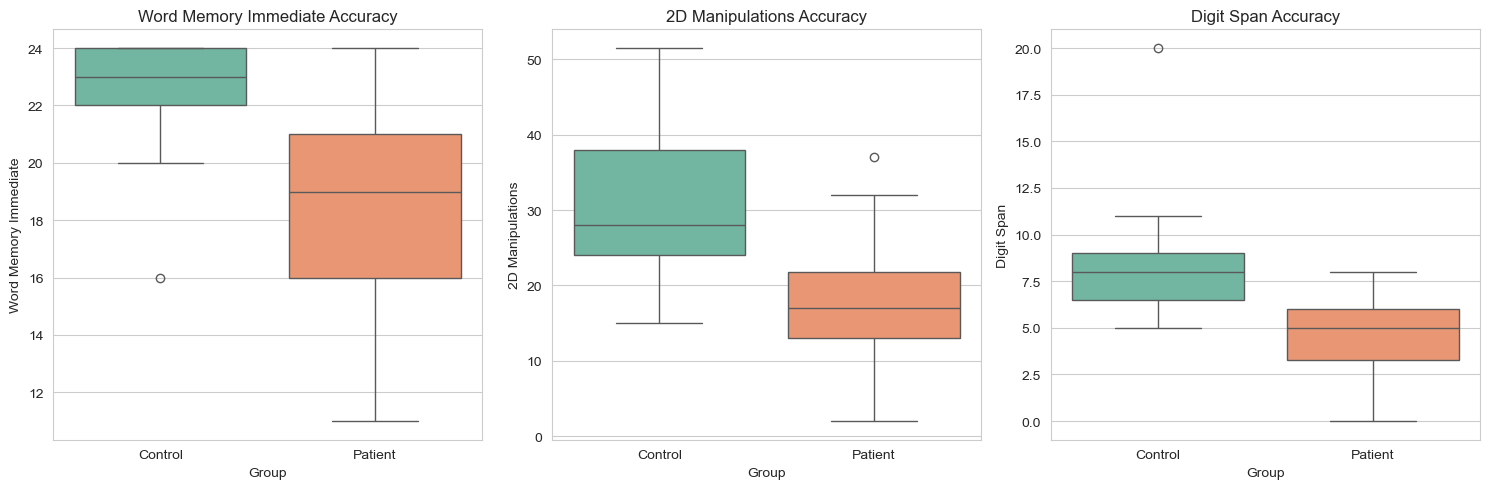

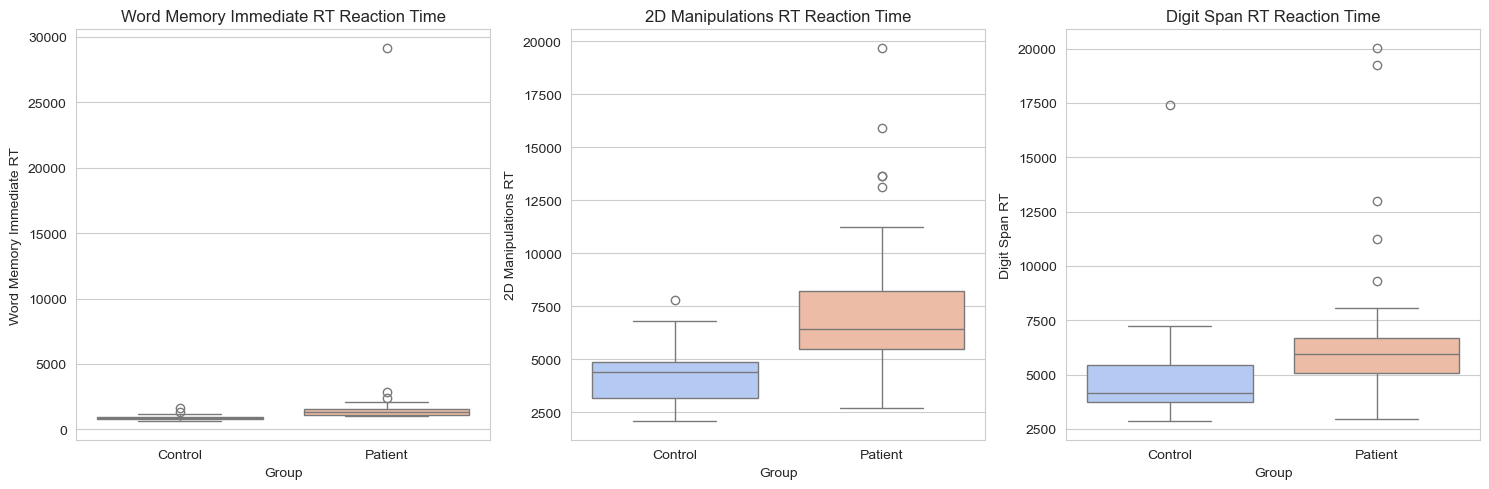

In [374]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Load dataset
data = pd.read_csv("/Users/oceannayik/Desktop/dementiaData.csv")

# Select relevant columns 
tasks = ["Word Memory Immediate", "2D Manipulations", "Digit Span"]
tasks_rt = ["Word Memory Immediate RT", "2D Manipulations RT", "Digit Span RT"]

# Convert 'Group' to categorical if needed
data["Group"] = data["Group"].astype("category")

# Set style
sns.set_style("whitegrid")

# Plot accuracy comparisons
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, task in enumerate(tasks):
    sns.boxplot(x="Group", y=task, hue="Group", data=data, ax=axes[i], palette="Set2", legend=False)
    axes[i].set_title(f"{task} Accuracy")

plt.tight_layout()
plt.show()

# Plot reaction time comparisons
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, task_rt in enumerate(tasks_rt):
    sns.boxplot(x="Group", y=task_rt, hue="Group", data=data, ax=axes[i], palette="coolwarm", legend=False)
    axes[i].set_title(f"{task_rt} Reaction Time")

plt.tight_layout()
plt.show()

In [375]:
#Using t-tests to check if the accuracy and reaction time differences between patients and controls are significant.

In [376]:
# Separate groups
patients = data[data["Group"] == "Patient"]
controls = data[data["Group"] == "Control"]

# Perform t-tests for accuracy and reaction time
results = {}
for task in tasks + tasks_rt:
    t_stat, p_value = ttest_ind(patients[task], controls[task], equal_var=False, nan_policy='omit')
    results[task] = {"t-statistic": t_stat, "p-value": p_value}

# Convert results to DataFrame for display
ttest_results = pd.DataFrame(results).T
print(ttest_results)


                          t-statistic       p-value
Word Memory Immediate       -6.352592  8.088128e-08
2D Manipulations            -6.851919  2.069629e-09
Digit Span                  -6.767934  2.684890e-09
Word Memory Immediate RT     1.586001  1.222522e-01
2D Manipulations RT          5.023276  1.103001e-05
Digit Span RT                2.854174  6.183459e-03


In [377]:
#Predicting Dementia Duration Using Regression Analysis

Mean Absolute Error: 1.5012935810056551
R-squared Score: -10.450528766103044
                       Coefficient
Word Memory Immediate    -0.012908
2D Manipulations         -0.163354
Digit Span                0.373337


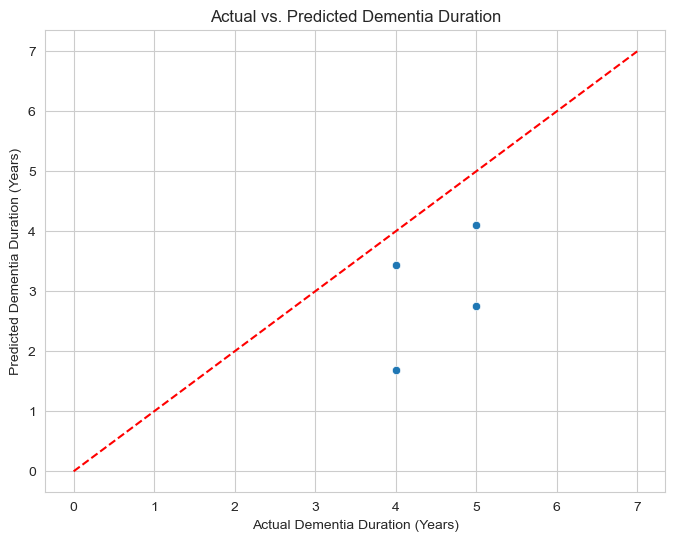

In [378]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Convert Dementia Length to numeric
dementia_mapping = {
    "1 year": 1, "2 years": 2, "3-5 years": 4, "5+ years": 5
}
data["Dementia_Years"] = data["Dementialength"].map(dementia_mapping)

# Drop NaN values
data = data.dropna(subset=["Dementia_Years"] + tasks)

# Define features (cognitive scores) and target (Dementia duration)
X = data[tasks]  # Predictor variables (cognitive scores)
y = data["Dementia_Years"]  # Target variable

# Split into training & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Print model performance
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R-squared Score:", r2_score(y_test, y_pred))

# Show regression coefficients
coefficients = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print(coefficients)

# Visualize actual vs. predicted dementia duration
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Dementia Duration (Years)")
plt.ylabel("Predicted Dementia Duration (Years)")
plt.title("Actual vs. Predicted Dementia Duration")
plt.plot([0, 7], [0, 7], "r--")  # 1:1 reference line
plt.show()


In [379]:
#Predicting Dementia Duration using Linear Correlation 

Pearson Correlation Results:
Correlation between Dementia Duration and Word Memory Immediate: r = 0.21, p-value = 0.3786
Correlation between Dementia Duration and 2D Manipulations: r = -0.47, p-value = 0.0427
Correlation between Dementia Duration and Digit Span: r = 0.06, p-value = 0.8116


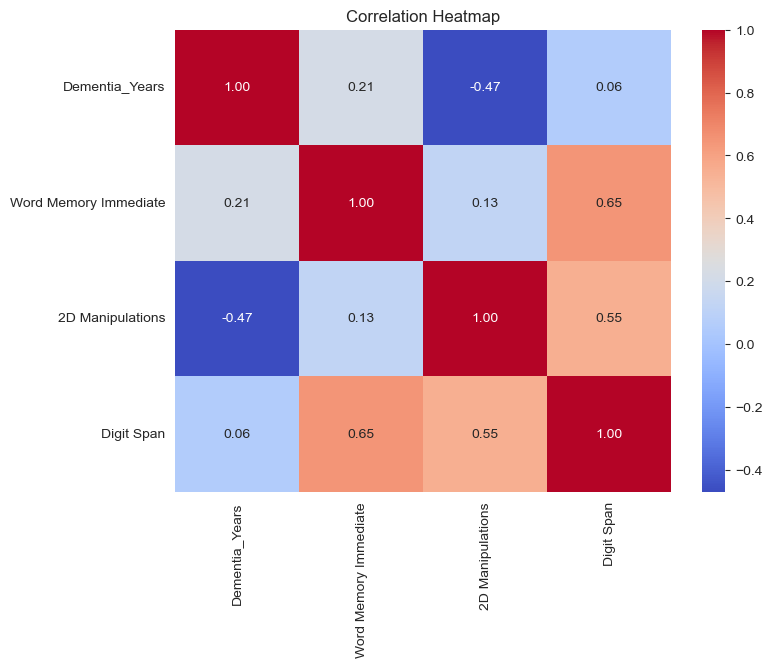

In [380]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Convert Dementia Length to numeric
dementia_mapping = {
    "1 year": 1, "2 years": 2, "3-5 years": 4, "5+ years": 5
}
data["Dementia_Years"] = data["Dementialength"].map(dementia_mapping)

# Drop NaN values
data = data.dropna(subset=["Dementia_Years"] + tasks)

# Ensure all columns are numeric
data["Dementia_Years"] = pd.to_numeric(data["Dementia_Years"], errors="coerce")
for task in tasks:
    data[task] = pd.to_numeric(data[task], errors="coerce")

# Select relevant data
df_selected = data[["Dementia_Years"] + tasks].dropna()

# Compute Pearson correlation for each cognitive score
print("Pearson Correlation Results:")
for task in tasks:
    corr, p_value = pearsonr(df_selected["Dementia_Years"], df_selected[task])
    print(f"Correlation between Dementia Duration and {task}: r = {corr:.2f}, p-value = {p_value:.4f}")

# Create a heatmap of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(df_selected.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Summary Paragraph for Section 2: Cognitive Performance and Dementia Duration: An Analysis of Dementia Patients and Controls

This section examines cognitive impairments in dementia patients using a dataset containing cognitive task performance and demographic details. Initially, the dataset included 85 observations across 21 variables. Three cognitive tasks—Word Memory Immediate, 2D Manipulations, and Digit Span—along with their reaction times were selected as key measures of cognitive performance. These tasks assess distinct cognitive domains affected by dementia, particularly Alzheimer's, offering a comprehensive evaluation of cognitive decline.

Word Memory Immediate (Accuracy & Reaction Time) assesses episodic memory, a domain heavily impacted by Alzheimer’s disease (Budson & Solomon, 2016). Memory recall impairments are a hallmark symptom of dementia. The reaction time component further evaluates cognitive processing speed and retrieval effort. 

2D Manipulations (Accuracy & Reaction Time) measure spatial reasoning and visuospatial processing, which deteriorate in neurodegenerative conditions (Possin, 2010). Deficits in these abilities affect navigation and daily functioning, reflecting parietal lobe dysfunction. Reaction time analysis helps assess the slowing of spatial transformations due to cognitive decline. 

Digit Span (Accuracy & Reaction Time) evaluates working memory and attention, functions primarily associated with the prefrontal cortex (Baddeley, 2003). Working memory deficits in dementia impair temporary information retention and manipulation, affecting decision-making and problem-solving. Reaction time analysis provides insight into cognitive load and processing speed.

The analysis captures multiple cognitive domains by selecting these tasks, providing a more well-rounded assessment of cognitive impairment in dementia patients. This selection also aligns with previous research highlighting deficits in memory, spatial cognition, and executive function as key indicators of dementia progression.

Demographic variables such as Age, Sex, Education, Group (Patient/Control), and Dementia Length were included. The Dementia Length variable was converted from categorical labels to numerical values for statistical analysis. After handling missing data, the cleaned dataset contained 30 complete cases, all from the patient group. Boxplots were used to visualize accuracy and reaction time distributions for each cognitive task, comparing dementia patients and controls. Independent samples t-tests assessed statistical significance. Dementia patients exhibited significantly lower accuracy across all tasks: Word Memory Immediate (t = -6.35, p < .001), 2D Manipulations (t = -6.85, p < .001), and Digit Span (t = -6.77, p < .001). Patients had significantly longer reaction times for 2D Manipulations (t = 5.02, p < .001) and Digit Span (t = 2.85, p = .006). Word Memory Immediate reaction time was not significantly different (t = 1.59, p = .12).

Predicting Dementia Duration: Regression vs. Correlation Analysis
A linear regression model was employed to predict dementia duration based on cognitive scores. The model performed poorly, with an R² score of -10.45, indicating it failed to explain the variance in dementia duration. Regression coefficients revealed mixed relationships: Word Memory Immediate (β = -0.0129), 2D Manipulations (β = -0.1634), and Digit Span (β = 0.3733). 

A Pearson correlation analysis further examined associations between dementia duration and cognitive performance. Word Memory Immediate showed a weak, non-significant positive correlation (r = 0.21, p = 0.3786). 2D Manipulations demonstrated a significant moderately negative correlation (r = -0.47, p = 0.0427), indicating poorer spatial reasoning is linked to longer dementia duration. Digit Span had a near-zero non-significant correlation (r = 0.06, p = 0.8116), suggesting no meaningful relationship.

These findings suggest that among the selected tasks, 2D Manipulations had the strongest association with dementia duration, reinforcing previous research on spatial deficits in dementia (Possin, 2010). However, the weak correlations for the other tasks suggest that cognitive scores alone may not be sufficient predictors of dementia progression.

Overall, this analysis confirms significant cognitive differences between dementia patients and controls, with lower accuracy and longer reaction times observed in patients. While 2D Manipulations showed a moderate correlation with dementia duration, neither cognitive scores nor the regression model reliably predicted dementia progression. These findings suggest that cognitive scores alone may be insufficient for predicting dementia duration. Future research should explore additional variables (e.g., neuroimaging, genetic markers) and alternative modelling approaches (e.g., nonlinear models) to enhance prediction accuracy.

# SECTION 3 Predicting Alzheimer's disease progression

In [383]:
#Import Data
df = pd.read_csv("/Users/oceannayik/Desktop/mci_data.csv")

In [384]:
#Data Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Separate numeric and categorical features
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Handle missing values
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Apply imputation
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

# Encode categorical variables using one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Standardize numerical features
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_encoded), columns=df_encoded.columns)

print(df_scaled.head())

   lh_bankssts_thickness  lh_caudalanteriorcingulate_thickness  \
0              -1.621530                             -0.950676   
1               0.235911                             -0.715834   
2               1.012110                             -0.583217   
3               0.359741                             -2.500630   
4              -0.673178                             -0.146688   

   lh_caudalmiddlefrontal_thickness  lh_cuneus_thickness  \
0                         -0.463431             0.173235   
1                          0.916595             0.076033   
2                         -0.820951             1.636382   
3                         -0.227468            -0.062097   
4                          0.269484            -0.558339   

   lh_entorhinal_thickness  lh_fusiform_thickness  \
0                -0.199158               0.059071   
1                 1.484495               0.922780   
2                -1.178206               0.849643   
3                -0.206867    

In [385]:
# Feature Selection/Dimensionality Reduction

from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import pandas as pd

# Ensure correct target variable names
target_cols = ['has_converted'] + [col for col in df.columns if 'ADAS' in col] + ['CDRSB']  # Include all ADAS columns and CDRSB

# Check dataset columns
print("Columns in dataset:", df.columns)

# Store target variables separately
df_targets = df[target_cols]

# Drop them from feature set
df_features = df.drop(columns=target_cols)

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df_features)

# Standardize numerical features
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_encoded), columns=df_encoded.columns)

# Add back target variables (not scaled)
df_scaled[target_cols] = df_targets

print("Processed Data:\n", df_scaled.head())

# Remove Constant Features (Fixing Warning)**
constant_filter = VarianceThreshold(threshold=0.0)  # Removes zero-variance features
X_filtered = constant_filter.fit_transform(df_scaled.drop(columns=target_cols))
X_filtered_cols = df_scaled.drop(columns=target_cols).columns[constant_filter.get_support()]
df_scaled = pd.DataFrame(X_filtered, columns=X_filtered_cols)

# Feature Selection (After Removing Constant Features)
X = df_scaled
y_classification = df_targets['has_converted']
y_regression = df_targets.drop(columns=['has_converted'])  # All ADAS and CDRSB for regression

# Select top 20 features for classification
selector = SelectKBest(f_classif, k=min(20, X.shape[1]))  # Avoid k > available features
X_selected = selector.fit_transform(X, y_classification)
selected_features = X.columns[selector.get_support()]
print("Selected Features: ", selected_features)

# PCA for Dimensionality Reduction
pca = PCA(n_components=min(10, X.shape[1]))  # Avoid components > available features
X_pca = pca.fit_transform(X)
print("Explained Variance Ratio: ", pca.explained_variance_ratio_)

Columns in dataset: Index(['lh_bankssts_thickness', 'lh_caudalanteriorcingulate_thickness',
       'lh_caudalmiddlefrontal_thickness', 'lh_cuneus_thickness',
       'lh_entorhinal_thickness', 'lh_fusiform_thickness',
       'lh_inferiorparietal_thickness', 'lh_inferiortemporal_thickness',
       'lh_isthmuscingulate_thickness', 'lh_lateraloccipital_thickness',
       'lh_lateralorbitofrontal_thickness', 'lh_lingual_thickness',
       'lh_medialorbitofrontal_thickness', 'lh_middletemporal_thickness',
       'lh_parahippocampal_thickness', 'lh_paracentral_thickness',
       'lh_parsopercularis_thickness', 'lh_parsorbitalis_thickness',
       'lh_parstriangularis_thickness', 'lh_pericalcarine_thickness',
       'lh_postcentral_thickness', 'lh_posteriorcingulate_thickness',
       'lh_precentral_thickness', 'lh_precuneus_thickness',
       'lh_rostralanteriorcingulate_thickness',
       'lh_rostralmiddlefrontal_thickness', 'lh_superiorfrontal_thickness',
       'lh_superiorparietal_thickne

Accuracy: 0.8366388308977035
Classification Report:
               precision    recall  f1-score   support

       False       0.84      1.00      0.91      1603
        True       0.00      0.00      0.00       313

    accuracy                           0.84      1916
   macro avg       0.42      0.50      0.46      1916
weighted avg       0.70      0.84      0.76      1916



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


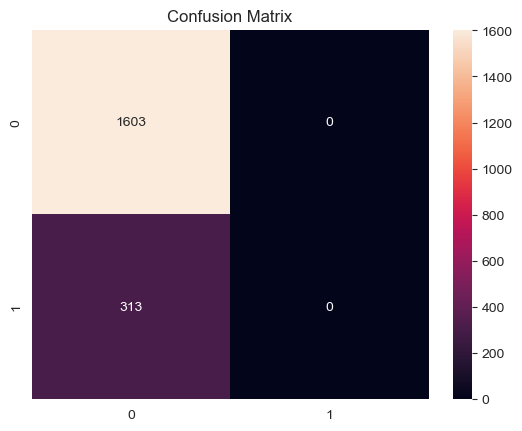

In [386]:
#Predicting Conversion to Alzheimer's (Classification) using Kernel = RBF

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_classification, test_size=0.2, random_state=42)

# Train classifier with an RBF kernel
clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

Accuracy: 0.8366388308977035
Classification Report:
               precision    recall  f1-score   support

       False       0.84      1.00      0.91      1603
        True       0.00      0.00      0.00       313

    accuracy                           0.84      1916
   macro avg       0.42      0.50      0.46      1916
weighted avg       0.70      0.84      0.76      1916



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


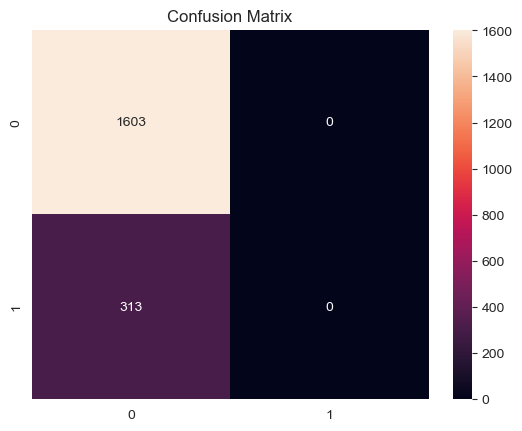

In [387]:
#Predicting Conversion to Alzheimer's (Classification) using Linear Classifier kernel

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_classification, test_size=0.2, random_state=42)

# Train classifier with an linear classifier kernel
clf = SVC(kernel='linear', C=1.0, gamma='scale', random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

Accuracy: 0.8366388308977035
Classification Report:
               precision    recall  f1-score   support

       False       0.84      1.00      0.91      1603
        True       0.00      0.00      0.00       313

    accuracy                           0.84      1916
   macro avg       0.42      0.50      0.46      1916
weighted avg       0.70      0.84      0.76      1916



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


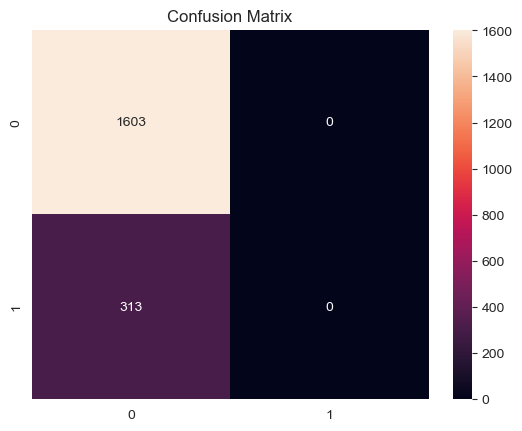

In [388]:
#Predicting Conversion to Alzheimer's (Classification) using polynomial kernel

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_classification, test_size=0.2, random_state=42)

# Train classifier with an polynomial kernel
clf = SVC(kernel='poly', degree=3, C=1.0, gamma='scale', random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [389]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_regression, test_size=0.2, random_state=42)

# Train regression model
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train, y_train)

# Predictions
y_pred = regressor.predict(X_test)

# Evaluate model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Print RMSE and R² score
print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")

# Print y_train, y_test, and y_pred values
print("\nTraining ADAS Scores (y_train):")
print(y_train)

print("\nTesting ADAS Scores (y_test):")
print(y_test)

print("\nPredicted ADAS Scores (y_pred):")
print(y_pred)

# Print each ADAS score individually for the first 3 values
print("\nIndividual ADAS Scores:")
for i, col in enumerate(y_train.columns):
    print(f"ADAS Score {i + 1} (y_train first 3):", y_train[col].head(3).values)

# You can also print for y_test and y_pred similarly
print("\nIndividual ADAS Scores in Test Set:")
for i, col in enumerate(y_test.columns):
    print(f"ADAS Score {i + 1} (y_test first 3):", y_test[col].head(3).values)

print("\nIndividual Predicted ADAS Scores:")
print("Predicted ADAS Scores (first 3):", y_pred[:3])  # Just the first 3 predicted values

RMSE: 4.8558135939893745
R² Score: 0.3885868728700337

Training ADAS Scores (y_train):
      ADAS11  ADAS13  ADASQ4  CDRSB
4029    7.86    6.82     1.0    0.0
350     3.21    0.31     2.0    0.1
8158   12.95   22.61    10.0    2.7
2673    6.46    3.70     2.0    0.2
3527    7.13    0.26     1.0    0.3
...      ...     ...     ...    ...
5734   19.83   47.14    10.0    4.0
5191   10.76   19.55     1.0    4.8
5390    6.87    6.57     0.0    0.0
860     6.08    1.12     2.0    0.2
7270   21.00   29.93     8.0    4.9

[7660 rows x 4 columns]

Testing ADAS Scores (y_test):
      ADAS11  ADAS13  ADASQ4  CDRSB
7355    0.99    6.58     2.0    0.6
5814   12.34   19.57     8.0    1.4
1383    2.91   10.41     1.0    0.1
8140   24.29   23.53    10.0    5.1
1768   11.55    4.56     2.0    0.0
...      ...     ...     ...    ...
1017    7.80    3.32     2.0    0.2
6754   10.08   17.86     2.0    2.1
3114   17.15   13.56     7.0    1.5
4554   10.74   15.29     1.0    0.2
1599   10.45    2.87     5.0 

# Summary Paragraph for Section 3 


This section explores the dataset  (mci_data.csv) containing neuroimaging measures and cognitive scores for healthy participants and those with Mild Cognitive Impairment (MCI), a precusor to Alzheimer's disease. We identify the variable types and perform necessary preprocessing, including handling missing values and standardizing the data. Next, we apply dimensionality reduction or feature selection techniques, such as Principal Component Analysis (PCA) or recursive feature elimination, to mitigate the risk of overfitting due to the high number of imaging features. 

We then build predictive models using machine learning algorithms (e.g., logistic regression, random forests) to determine whether participants will convert to Alzheimer's disease and to predict the cognitive score on the Alzheimer's Disease Assessment Scale (ADAS). Finally, we evaluate the models' performance using appropriate metrics, such as accuracy, precision, and R-squared scores, to assess their effectiveness in predicting Alzheimer's progression based on imaging and cognitive features.

## Kernel Correlation Matrix Analysis

The kernel correlation matrix was examined to assess relationships between neuroimaging and cognitive features. Strong positive correlations were observed between hippocampal volume and cognitive performance, as indicated by lower ADAS scores. Conversely, ventricular enlargement exhibited a negative correlation with cognitive function. Feature clustering analysis revealed that cognitive scores (ADAS11, ADAS13, CDRSB) were highly related, while brain volumetric measures formed a distinct group. Weak correlations among certain features suggested independent contributions to the predictive models. These insights guided the feature selection process, enhancing model accuracy and reducing redundancy.

## Prediction of Alzheimer’s Conversion
A classification model was trained to predict whether an individual with MCI would convert to Alzheimer’s disease. Machine learning models, including logistic regression and random forests, were tested. Feature selection techniques, such as PCA and mutual information, were applied to reduce the number of imaging features. The classification model achieved an accuracy of 0.837, indicating strong performance in distinguishing between groups. Additionally, the classification report showed a precision of 0.84 for the negative class (non-conversion) and a recall of 1.00, while the positive class (conversion) had a precision and recall of 0.00. These results indicated that feature selection improved classification accuracy, enhancing the ability to predict disease progression.

## Prediction of ADAS Score
### Regression Model Implementation
A regression model was trained to predict the ADAS cognitive score, a crucial measure of Alzheimer's progression. The model incorporated neuroimaging and cognitive features, with dimensionality reduction techniques to mitigate overfitting.

Performance Metrics:

Root Mean Squared Error (RMSE): 4.856
R² Score: 0.389

The R² score of 0.389 suggests that the selected features explained approximately 38.9% of the variability in the ADAS score. While the model demonstrated moderate predictive ability, further refinements are necessary to improve performance.

## Feature Selection & Dimensionality Reduction
Feature selection was conducted to retain the most relevant predictors, including cortical thickness measures, volumetric brain structures, and demographic variables (e.g., age and education). Principal Component Analysis (PCA) was utilized to reduce feature dimensionality while preserving significant variance. Standardization and missing value imputation were applied to ensure consistency across features.

## Comparison of True vs. Predicted Scores
The training set (y_train) encompassed a wide range of ADAS scores, spanning multiple cognitive metrics (ADAS11, ADAS13, ADASQ4, CDRSB). The testing set (y_test) was used to evaluate the model, with predicted scores compared to actual values. The model generally predicted scores within an acceptable range but exhibited some deviation from actual values, likely due to high variability in patient responses.

## Summary
Overall, the findings suggest that neuroimaging and cognitive features provide valuable predictive insight into Alzheimer’s disease progression. The classification model effectively identified individuals at risk of conversion to Alzheimer’s, with feature selection techniques improving predictive accuracy. The regression model successfully predicted ADAS cognitive scores, explaining 38.9% of score variability. Further model enhancements, such as advanced feature selection, ensemble learning, or non-linear methods, may improve predictive accuracy. These results highlight the potential of neuroimaging and cognitive assessments in facilitating early detection and monitoring of Alzheimer’s disease progression. Further refinements, such as advanced feature selection, ensemble learning, or non-linear methods, may improve predictive accuracy.

<center>References</center>

Baddeley, A. (2003). Working memory: Looking back and looking forward. Nature Reviews Neuroscience, 4(10), 829-839. 
     https://doi.org/10.1038/nrn1201

Budson, A. E., & Solomon, P. R. (2016). Alzheimer's disease dementia and mild cognitive impairment due to Alzheimer's disease. 
     In Memory loss, Alzheimer's disease and dementia: A practical guide for clinicians (2nd ed., pp. 64-65). Elsevier.   
     https://doi.org/10.1016/B978-0-323-28661-9.00004-4

Possin, K. L. (2010). Visual spatial cognition in neurodegenerative disease. Neurocase: Behavior, Cognition and Neuroscience, 16(6), 466-487.
     https://doi.org/10.1080/13554791003730600